In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [2]:
data = pd.read_csv("Food_Nutrition_Dataset.csv")
data.head()

,food_name,category,calories,protein,carbs,fat,iron,vitamin_c
0,"Apple, candied",Apples,134.0,1.34,29.61,2.15,0.12,3.6
1,"Apple, raw",Apples,61.0,0.17,14.80,0.15,0.03,4.6
2,"Apple, dried",Dried fruits,243.0,0.93,65.89,0.32,1.40,3.9
3,"Crisp, apple",Cakes and pies,215.0,2.81,30.18,9.59,1.00,0.6
4,"Apple, baked",Apples,113.0,0.32,22.70,3.08,0.19,3.9


In [3]:
print(data.columns)

Index(['food_name', 'category', 'calories', 'protein', 'carbs', 'fat', 'iron',
       'vitamin_c'],
      dtype='object')


In [4]:

data = pd.get_dummies(data, columns=['category'])
data = data.drop(['food_name'], axis=1)
data = data[(data["calories"] > 10) & (data["calories"] < 800)]

In [5]:
X = data.drop("calories", axis=1)
y = data["calories"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [8]:
model = RandomForestRegressor(
    n_estimators=300,
    max_depth=25,
    min_samples_split=3,
    min_samples_leaf=2,
    random_state=42
)
model.fit(X_train, y_train)

,n_estimators,300
,criterion,'squared_error'
,max_depth,25
,min_samples_split,3
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [9]:
y_pred = model.predict(X_test)

In [10]:
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 44.24625428892093
R2 Score: 0.7255777966739854


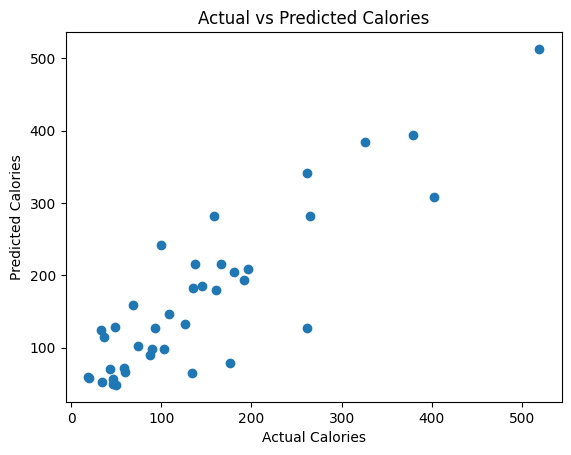

In [11]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Calories")
plt.ylabel("Predicted Calories")
plt.title("Actual vs Predicted Calories")
plt.show()